<a href="https://colab.research.google.com/github/diegofranco22df-alt/Proyecto-RappiPlus-De-datos-a-decisiones-de-negocio/blob/main/S12%20Proyecto_Rappiplus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarse con la estructura de los datasets del negocio antes de analizarlos.

- Importar las librerías necesarias
- Cargar los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guardar los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explorar cada dataset.

---

In [ ]:
# importar librerías
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [ ]:
# explorar datasets
orders.info()
print()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB



,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [ ]:
catalog.info()
print()
catalog.head(7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes



,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [ ]:
marketing.info()
print()
marketing.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB



,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [ ]:
# 1. Validar y convertir fechas al formato correcto
# Verificar tipo de dato
print(orders['fecha_hora_pedido'].dtype)

object


In [ ]:
# Convertir a tipo fecha
orders['fecha_hora_pedido']= pd.to_datetime(orders['fecha_hora_pedido'], errors='coerce')

# Ver cuántas fechas quedaron como NaT
orders['fecha_hora_pedido'].isna().sum()

0

In [ ]:
# Ver el rango de fechas para detectar años extraños
orders['fecha_hora_pedido'].dt.year.value_counts()

2025    25100
Name: fecha_hora_pedido, dtype: int64

In [ ]:
# Convertir a tipo fecha
marketing['fecha']= pd.to_datetime(marketing['fecha'], errors='coerce')

# Ver cuántas fechas quedaron como NaT
marketing['fecha'].isna().sum()

0

In [ ]:
# Ver el rango de fechas para detectar años extraños
marketing['fecha'].dt.year.value_counts()

2025    1620
Name: fecha, dtype: int64

In [ ]:
# 2. Revisar variables numéricas
# Revisar variables con errores

# Revisar cantidad
print("Cantidad <= 0:")
print(orders[orders['cantidad'] <= 0]['cantidad'].value_counts())

# Revisar precio_unitario
print("\nPrecio unitario <= 0:")
print(orders[orders['precio_unitario'] <= 0]['precio_unitario'].value_counts())

# Revisar monto_descuento negativo
print("\nDescuentos negativos:")
print(orders[orders['monto_descuento'] < 0]['monto_descuento'].value_counts())

# Revisar monto_total
print("\nMonto total <= 0:")
print(orders[orders['monto_total'] <= 0]['monto_total'].value_counts())

Cantidad <= 0:
-1.0    3
-2.0    1
Name: cantidad, dtype: int64

Precio unitario <= 0:
Series([], Name: precio_unitario, dtype: int64)

Descuentos negativos:
Series([], Name: monto_descuento, dtype: int64)

Monto total <= 0:
-492.65    1
-423.53    1
-192.62    1
-38.50     1
Name: monto_total, dtype: int64


In [ ]:
problemas = orders[
    (orders['cantidad'] <= 0) |
    (orders['precio_unitario'] <= 0) |
    (orders['monto_descuento'] < 0) |
    (orders['monto_total'] <= 0)
]

print("Registros con problemas:")
print(problemas[['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']])

Registros con problemas:
     cantidad  precio_unitario  monto_descuento  monto_total
266      -2.0           101.31             10.0      -192.62
267      -1.0            43.50              5.0       -38.50
268      -1.0           497.65              5.0      -492.65
269      -1.0           423.53              0.0      -423.53


In [ ]:
# Eliminar los registros con problemas
indices_problematicos = problemas.index
print(f"Índices a eliminar: {list(indices_problematicos)}")

# Crear dataset limpio sin estos registros
orders_clean = orders.drop(indices_problematicos)

print(f"Registros originales: {len(orders)}")
print(f"Registros después de limpieza: {len(orders_clean)}")
print(f"Registros eliminados: {len(orders) - len(orders_clean)}")

Índices a eliminar: [266, 267, 268, 269]
Registros originales: 25100
Registros después de limpieza: 25096
Registros eliminados: 4


- Decidí eliminar los 4 registros con montos negativos, ya que no es posible que hayan ventas negativas.
- Los 4 registros eliminados no son representativos, equivalen al 0.016% de los datos

In [ ]:
# Verificar cambios
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25096 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25096 non-null  object        
 1   id_usuario          25096 non-null  object        
 2   fecha_hora_pedido   25096 non-null  datetime64[ns]
 3   pais                24800 non-null  object        
 4   dispositivo         25076 non-null  object        
 5   fuente_referencia   25066 non-null  object        
 6   nombre_producto     25066 non-null  object        
 7   categoria_producto  25016 non-null  object        
 8   cantidad            25046 non-null  float64       
 9   precio_unitario     25046 non-null  float64       
 10  monto_descuento     25046 non-null  float64       
 11  monto_total         25096 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.5+ MB


In [ ]:
# Analizar datos faltantes en la columna país
print("=== Análisis de datos faltantes en País ===")
print(f"Total de registros: {len(orders_clean)}")
print(f"Registros con país: {orders_clean['pais'].notna().sum()}")
print(f"Registros sin país: {orders_clean['pais'].isna().sum()}")
print(f"Porcentaje de datos faltantes: {(orders_clean['pais'].isna().sum() / len(orders_clean)) * 100:.2f}%")

# Ver si hay patrones en los datos faltantes
print("\n=== Patrones en datos faltantes ===")
missing_data = orders_clean[orders_clean['pais'].isna()]
print(f"Registros con país faltante: {len(missing_data)}")

# Verificar si hay patrones por otras variables
print("\nDistribución por dispositivo en datos faltantes:")
print(missing_data['dispositivo'].value_counts(dropna=False))

print("\nDistribución por fuente_referencia en datos faltantes:")
print(missing_data['fuente_referencia'].value_counts(dropna=False))

=== Análisis de datos faltantes en País ===
Total de registros: 25096
Registros con país: 24800
Registros sin país: 296
Porcentaje de datos faltantes: 1.18%

=== Patrones en datos faltantes ===
Registros con país faltante: 296

Distribución por dispositivo en datos faltantes:
mobile     154
desktop    142
Name: dispositivo, dtype: int64

Distribución por fuente_referencia en datos faltantes:
paid_search    114
social         107
organic         75
Name: fuente_referencia, dtype: int64


- Se analizó los patrones en datos faltantes, por distribución de dispositivo y fuente referencia.
- Los datos faltantes parecen aleatorios, no hay un patrón marcado de faltantes en las variables analizadas.
- Los datos faltantes por cada tipo de variable son similares.

In [ ]:
# Rellenar valores faltantes en país con una categoría especial
orders_clean['pais'] = orders_clean['pais'].fillna('Pais_sin_especificar')

# Verificar que funcionó
print("Verificación:")
print(f"Valores faltantes después: {orders_clean['pais'].isna().sum()}")
print(f"Registros 'País_sin_especificar': {(orders_clean['pais'] == 'Pais_sin_especificar').sum()}")

Verificación:
Valores faltantes después: 0
Registros 'País_sin_especificar': 296


In [ ]:
# Rellenar valores faltantes en dispositivo con categoría especial
orders_clean['dispositivo']= orders_clean['dispositivo'].fillna('Dispositivo_desconocido')

print("Verificación:")
print(f"Valores faltantes: {orders_clean['dispositivo'].isna().sum()}")
print(f"Dispositivo desconocido: {(orders_clean['dispositivo'] == 'Dispositivo_desconocido').sum()}")

Verificación:
Valores faltantes: 0
Dispositivo desconocido: 20


In [ ]:
# Rellenar valores faltantes en fuente_referencia
#Crear categoría
orders_clean['fuente_referencia']= orders_clean['fuente_referencia'].fillna('Canal_desconocido')

# Verificar
print("Verificación fuente_referencia:")
print(f"Valores faltantes: {orders_clean['fuente_referencia'].isna().sum()}")
print(f"Canal desconocido: {(orders_clean['fuente_referencia'] == 'Canal_desconocido').sum()}")

Verificación fuente_referencia:
Valores faltantes: 0
Canal desconocido: 30


In [ ]:
# Rellenar valores faltantes en nombre_producto
# Opción 1: Crear categoría "Producto_no_especificado"
orders_clean['nombre_producto'] = orders_clean['nombre_producto'].fillna('Producto_no_especificado')

# Verificar
print("Verificación nombre_producto:")
print(f"Valores faltantes: {orders_clean['nombre_producto'].isna().sum()}")
print(f"Producto no especificado: {(orders_clean['nombre_producto'] == 'Producto_no_especificado').sum()}")

Verificación nombre_producto:
Valores faltantes: 0
Producto no especificado: 30


In [ ]:
# Ver qué productos tienen categoría faltante
productos_sin_categoria = orders_clean[orders_clean['categoria_producto'].isna()]
print("Productos sin categoría:")
print(productos_sin_categoria['nombre_producto'].value_counts())

# Ver las categorías disponibles en el catálogo
print("\nCategorías en el catálogo:")
print(catalog[['nombre_producto', 'categoria_producto']])

Productos sin categoría:
Producto_no_especificado    30
Sneakers-Urban-42           19
Jacket-Winter-M             10
Vacuum-Pro-Black             6
Tablet-Standard-64GB         5
Laptop-Gaming-16GB           4
Phone-Pro-128GB              3
Blender-XL-Red               3
Name: nombre_producto, dtype: int64

Categorías en el catálogo:
        nombre_producto categoria_producto
0    Laptop-Gaming-16GB        Electrónica
1       Phone-Pro-128GB        Electrónica
2  Tablet-Standard-64GB        Electrónica
3        Blender-XL-Red              Hogar
4      Vacuum-Pro-Black              Hogar
5     Sneakers-Urban-42               Moda
6       Jacket-Winter-M               Moda


In [ ]:
# Crear un diccionario de mapeo desde el catálogo
mapeo_categorias = dict(zip(catalog['nombre_producto'], catalog['categoria_producto']))
print("Mapeo de categorías:")
print(mapeo_categorias)

# Rellenar las categorías faltantes usando el mapeo
def asignar_categoria(row):
    if pd.isna(row['categoria_producto']) and row['nombre_producto'] in mapeo_categorias:
        return mapeo_categorias[row['nombre_producto']]
    elif pd.isna(row['categoria_producto']):
        return 'Categoria_no_especificada'
    else:
        return row['categoria_producto']

# Aplicar la función
orders_clean['categoria_producto'] = orders_clean.apply(asignar_categoria, axis=1)

# Verificar resultados
print("Verificación:")
print(f"Valores faltantes después: {orders_clean['categoria_producto'].isna().sum()}")
print(f"Categoría no especificada: {(orders_clean['categoria_producto'] == 'Categoria_no_especificada').sum()}")

Mapeo de categorías:
{'Laptop-Gaming-16GB': 'Electrónica', 'Phone-Pro-128GB': 'Electrónica', 'Tablet-Standard-64GB': 'Electrónica', 'Blender-XL-Red': 'Hogar', 'Vacuum-Pro-Black': 'Hogar', 'Sneakers-Urban-42': 'Moda', 'Jacket-Winter-M': 'Moda'}
Verificación:
Valores faltantes después: 0
Categoría no especificada: 30


In [ ]:
# Calcular promedios por nombre de producto específico
promedios_producto = orders_clean.groupby('nombre_producto').agg({
    'precio_unitario': 'mean',
    'cantidad': 'mean',
    'monto_descuento': 'mean'
}).round(2)

print("Promedios por producto:")
print(promedios_producto)

Promedios por producto:
                          precio_unitario  cantidad  monto_descuento
nombre_producto                                                     
Blender-XL-Red                     259.06      1.50             4.64
Jacket-Winter-M                    259.69      1.50             4.58
Laptop-Gaming-16GB                 261.28     51.69             4.59
Phone-Pro-128GB                    259.47      1.51             4.44
Producto_no_especificado           264.57      1.50             4.17
Sneakers-Urban-42                  257.10      1.49             4.41
Tablet-Standard-64GB               257.88      1.50             4.27
Vacuum-Pro-Black                   260.82      1.51             4.50


In [ ]:
# Analizar valores existentes de cantidad
print("=== Distribución de cantidad ===")
print(orders_clean['cantidad'].value_counts().sort_index())

print("\n=== Distribución de monto_descuento ===")
print(orders_clean['monto_descuento'].value_counts().sort_index())

=== Distribución de cantidad ===
1.0        12394
2.0        12642
10000.0        6
20000.0        4
Name: cantidad, dtype: int64

=== Distribución de monto_descuento ===
0.0     12550
5.0      4938
10.0     5067
15.0     2491
Name: monto_descuento, dtype: int64


In [ ]:
# Rellenar valores faltantes en precio_unitario, cantidad y monto_descuento
def rellenar_valores_faltantes(row):
    producto = row['nombre_producto']
    monto_total = row['monto_total']

    # Para registros con valores faltantes, usar monto_descuento = 0
    if pd.isna(row['precio_unitario']) or pd.isna(row['cantidad']) or pd.isna(row['monto_descuento']):
        descuento_final = 0

        # Usar precio promedio del producto como referencia
        if producto in promedios_producto.index:
            precio_referencia = promedios_producto.loc[producto, 'precio_unitario']
        else:
            precio_referencia = 260  # precio promedio general

        # Calcular cantidad como número entero basado en monto_total
        cantidad_estimada = monto_total / precio_referencia
        cantidad_final = max(1, round(cantidad_estimada))  # mínimo 1, redondeado

        # Ajustar precio_unitario para que coincida exactamente con monto_total
        precio_final = monto_total / cantidad_final

        return precio_final, cantidad_final, descuento_final
    else:
        # Si no hay valores faltantes, mantener los originales
        return row['precio_unitario'], row['cantidad'], row['monto_descuento']

In [ ]:
print(orders_clean.iloc[80])

id_pedido                        order_80
id_usuario                      user_6790
fecha_hora_pedido     2025-01-03 00:00:00
pais                               Mexico
dispositivo                       desktop
fuente_referencia                 organic
nombre_producto          Vacuum-Pro-Black
categoria_producto                  Hogar
cantidad                              NaN
precio_unitario                       NaN
monto_descuento                       NaN
monto_total                        711.18
Name: 80, dtype: object


In [ ]:
# Aplicar la función
for idx, row in orders_clean.iterrows():
    if pd.isna(row['precio_unitario']) or pd.isna(row['cantidad']) or pd.isna(row['monto_descuento']):
        precio, cantidad, descuento = rellenar_valores_faltantes(row)
        orders_clean.loc[idx, 'precio_unitario'] = precio
        orders_clean.loc[idx, 'cantidad'] = cantidad
        orders_clean.loc[idx, 'monto_descuento'] = descuento

print("=== Verificación ===")
print(f"Valores faltantes en precio_unitario: {orders_clean['precio_unitario'].isna().sum()}")
print(f"Valores faltantes en cantidad: {orders_clean['cantidad'].isna().sum()}")
print(f"Valores faltantes en monto_descuento: {orders_clean['monto_descuento'].isna().sum()}")

=== Verificación ===
Valores faltantes en precio_unitario: 0
Valores faltantes en cantidad: 0
Valores faltantes en monto_descuento: 0


In [ ]:
# Verificar que los cálculos sean consistentes
orders_clean['monto_calculado'] = (orders_clean['cantidad'] * orders_clean['precio_unitario']) - orders_clean['monto_descuento']
orders_clean['diferencia'] = abs(orders_clean['monto_total'] - orders_clean['monto_calculado'])

print("=== Verificación de consistencia ===")
print(f"Diferencias mayores a 0.01: {(orders_clean['diferencia'] > 0.01).sum()}")
print(f"Diferencia máxima: {orders_clean['diferencia'].max():.2f}")

=== Verificación de consistencia ===
Diferencias mayores a 0.01: 1146
Diferencia máxima: 0.01


In [ ]:
# Visualizar categorías únicas
orders_clean['categoria_producto'].value_counts()

Hogar                        8394
Moda                         8352
Electronica                  8308
Categoria_no_especificada      30
Electrónica                    12
Name: categoria_producto, dtype: int64

In [ ]:
# Estandarizar datos categoria_producto en orders_clean
orders_clean['categoria_producto']= orders_clean['categoria_producto'].replace('Electrónica', 'Electronica')

# Revisar cambios
orders_clean['categoria_producto'].value_counts()

Hogar                        8394
Moda                         8352
Electronica                  8320
Categoria_no_especificada      30
Name: categoria_producto, dtype: int64

In [ ]:
# Revisar valores nulos dataset orders_value luego de limpieza
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25096 entries, 0 to 25099
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25096 non-null  object        
 1   id_usuario          25096 non-null  object        
 2   fecha_hora_pedido   25096 non-null  datetime64[ns]
 3   pais                25096 non-null  object        
 4   dispositivo         25096 non-null  object        
 5   fuente_referencia   25096 non-null  object        
 6   nombre_producto     25096 non-null  object        
 7   categoria_producto  25096 non-null  object        
 8   cantidad            25096 non-null  float64       
 9   precio_unitario     25096 non-null  float64       
 10  monto_descuento     25096 non-null  float64       
 11  monto_total         25096 non-null  float64       
 12  monto_calculado     25096 non-null  float64       
 13  diferencia          25096 non-null  float64   

In [ ]:
# Limpiar dataset de Marketing
# Analizar datos faltantes en canal
print("=== Análisis de datos faltantes en canal ===")
print(f"Total de registros: {len(marketing)}")
print(f"Registros con canal: {marketing['canal'].notna().sum()}")
print(f"Registros sin canal: {marketing['canal'].isna().sum()}")
print(f"Porcentaje de datos faltantes: {(marketing['canal'].isna().sum() / len(marketing)) * 100:.2f}%")

# Ver los valores únicos de canal
print("\n=== Valores únicos de canal ===")
print(marketing['canal'].value_counts(dropna=False))

=== Análisis de datos faltantes en canal ===
Total de registros: 1620
Registros con canal: 1519
Registros sin canal: 101
Porcentaje de datos faltantes: 6.23%

=== Valores únicos de canal ===
paid_search    507
organic        506
social         506
NaN            101
Name: canal, dtype: int64


In [ ]:
# Analizar si hay patrones en los datos faltantes
print("\n=== Patrones en datos faltantes ===")
missing_canal = marketing[marketing['canal'].isna()]

print("\nDistribución por id_campaña en datos faltantes:")
print(missing_canal['id_campaña'].value_counts())


=== Patrones en datos faltantes ===

Distribución por id_campaña en datos faltantes:
social_Argentina         12
organic_Mexico           12
paid_search_Mexico       11
paid_search_Argentina    11
social_Colombia          11
organic_Colombia         11
social_Mexico            11
organic_Argentina        11
paid_search_Colombia     11
Name: id_campaña, dtype: int64


- Se visualiza que la variable id_campaña contiene los nombres de los canales faltantes, se procederá a extraer la información para rellenar los canales faltantes.

In [ ]:
# Se extrae el canal del nombre de la campaña
def extraer_canal_de_campana(row):
    if pd.isna(row['canal']) and pd.notna(row['id_campaña']):
        campana = row['id_campaña'].lower()
        if 'organic' in campana:
            return 'organic'
        elif 'paid_search' in campana:
            return 'paid_search'
        elif 'social' in campana:
            return 'social'
        else:
            return 'Canal_desconocido'
    elif pd.isna(row['canal']):
        return 'Canal_desconocido'
    else:
        return row['canal']

In [ ]:
# Crear una copia del dataset original
marketing_clean = marketing.copy()

# Aplicar la función de extracción de canal
marketing_clean['canal'] = marketing_clean.apply(extraer_canal_de_campana, axis=1)

# Verificar que funcionó
print("Verificación marketing_clean:")
print(f"Valores faltantes en canal: {marketing_clean['canal'].isna().sum()}")
print(f"Distribución de canales:")
print(marketing_clean['canal'].value_counts())

Verificación marketing_clean:
Valores faltantes en canal: 0
Distribución de canales:
organic        540
paid_search    540
social         540
Name: canal, dtype: int64


In [ ]:
marketing_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


In [ ]:
# Estandarizar datos
# Contar valores únicos
catalog['categoria_producto'].value_counts()

Electrónica    3
Hogar          2
Moda           2
Name: categoria_producto, dtype: int64

In [ ]:
# Reemplazar nombres de categoría
catalog['categoria_producto']= catalog['categoria_producto'].replace('Electrónica', 'Electronica')

In [ ]:
# Visualizar cambios
print('Valores únicos')
catalog['categoria_producto'].value_counts()

Valores únicos


Electronica    3
Hogar          2
Moda           2
Name: categoria_producto, dtype: int64

In [ ]:
# Copiar dataset con datos limpios
catalog_clean= catalog.copy()

In [ ]:
# Visualizar catalog_clean
catalog_clean.head(7)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electronica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electronica,10.12,King Ltd
2,Tablet-Standard-64GB,Electronica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [ ]:
# 3. Verificar consistencia de montos
# Crear una columna con el cálculo esperado
orders_clean['monto_calculado'] = (orders_clean['cantidad'] * orders_clean['precio_unitario']) - orders_clean['monto_descuento']

In [ ]:
# Calcular la diferencia entre lo esperado y lo real
orders_clean['diferencia'] = abs(orders_clean['monto_total'] - orders_clean['monto_calculado'])

# Ver cuántos registros tienen diferencias significativas
print(f"Registros con diferencias > 0.01: {(orders_clean['diferencia'] > 0.01).sum()}")
print(f"Diferencia máxima: {orders_clean['diferencia'].max():.2f}")

Registros con diferencias > 0.01: 1146
Diferencia máxima: 0.01


In [ ]:
# 4. Eliminar duplicados
# Detectar espacios en columnas númericas
def detectar_espacios_numericos(df, columnas_numericas):
    """
    Detecta espacios en columnas que deberían ser numéricas
    """
    problemas = {}

    for columna in columnas_numericas:
        if columna in df.columns:
            # Convertir a string para buscar espacios
            valores_str = df[columna].astype(str)

            # Buscar valores con espacios
            con_espacios = valores_str.str.contains(' ', na=False)

            if con_espacios.any():
                problemas[columna] = {
                    'registros_con_espacios': con_espacios.sum(),
                    'ejemplos': valores_str[con_espacios].head(3).tolist()
                }

    return problemas

In [ ]:
# Definir columnas numéricas
columnas_numericas = ['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']

# Detectar espacios
problemas_numericos = detectar_espacios_numericos(orders_clean, columnas_numericas)

print("=== DETECCIÓN DE ESPACIOS EN COLUMNAS NUMÉRICAS ===")
if not problemas_numericos:
    print("No se encontraron espacios en columnas numéricas.")
else:
    print("⚠️ Se encontraron espacios:")
    for columna, info in problemas_numericos.items():
        print(f"{columna}: {info}")

=== DETECCIÓN DE ESPACIOS EN COLUMNAS NUMÉRICAS ===
No se encontraron espacios en columnas numéricas.


In [ ]:
# Verificar duplicados exactos en orders_clean
duplicados_orders_clean = orders_clean.duplicated()
print(f"Registros duplicados orders_clean: {duplicados_orders_clean.sum()}")

Registros duplicados orders_clean: 100


In [ ]:
# Eliminar duplicados exactos (mantiene el primero)
orders_clean = orders_clean.drop_duplicates()

In [ ]:
# Verificar cambios
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24996 entries, 0 to 24999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24996 non-null  object        
 1   id_usuario          24996 non-null  object        
 2   fecha_hora_pedido   24996 non-null  datetime64[ns]
 3   pais                24996 non-null  object        
 4   dispositivo         24996 non-null  object        
 5   fuente_referencia   24996 non-null  object        
 6   nombre_producto     24996 non-null  object        
 7   categoria_producto  24996 non-null  object        
 8   cantidad            24996 non-null  float64       
 9   precio_unitario     24996 non-null  float64       
 10  monto_descuento     24996 non-null  float64       
 11  monto_total         24996 non-null  float64       
 12  monto_calculado     24996 non-null  float64       
 13  diferencia          24996 non-null  float64   

In [ ]:
# Verificar duplicados exactos en marketing_clean
duplicados_marketing_clean = marketing_clean.duplicated()
print(f"Registros duplicados marketing_clean: {duplicados_marketing_clean.sum()}")

Registros duplicados marketing_clean: 0


In [ ]:
# 5. Revisar variables categóricas
# Ver qué valores únicos tiene cada variable categórica
print("=== PAÍSES ===")
print(orders_clean['pais'].value_counts())

print("\n=== DISPOSITIVOS ===")
print(orders_clean['dispositivo'].value_counts())

print("\n=== CATEGORÍAS ===")
print(orders_clean['categoria_producto'].value_counts())

=== PAÍSES ===
Colombia                7481
Mexico                  7478
Argentina               7259
mexico                   863
colombia                 823
argentina                796
Pais_sin_especificar     296
Name: pais, dtype: int64

=== DISPOSITIVOS ===
desktop                    12707
mobile                     12269
Dispositivo_desconocido       20
Name: dispositivo, dtype: int64

=== CATEGORÍAS ===
Hogar                        8355
Moda                         8324
Electronica                  8287
Categoria_no_especificada      30
Name: categoria_producto, dtype: int64


In [ ]:
# Corregir inconsistencias
orders_clean['pais'] = orders_clean['pais'].replace({'mexico': 'Mexico', 'colombia': 'Colombia', 'argentina': 'Argentina'})

In [ ]:
# Verificar cambios
print("=== PAÍSES ===")
print(orders_clean['pais'].value_counts())

print("\n=== DISPOSITIVOS ===")
print(orders_clean['dispositivo'].value_counts())

print("\n=== CATEGORÍAS ===")
print(orders_clean['categoria_producto'].value_counts())

=== PAÍSES ===
Mexico                  8341
Colombia                8304
Argentina               8055
Pais_sin_especificar     296
Name: pais, dtype: int64

=== DISPOSITIVOS ===
desktop                    12707
mobile                     12269
Dispositivo_desconocido       20
Name: dispositivo, dtype: int64

=== CATEGORÍAS ===
Hogar                        8355
Moda                         8324
Electronica                  8287
Categoria_no_especificada      30
Name: categoria_producto, dtype: int64


In [ ]:
# Ver qué valores únicos tiene cada variable categórica
print("=== PAÍSES ===")
print(marketing_clean['pais'].value_counts())

print("\n=== ID CAMPAÑA ===")
print(marketing_clean['id_campaña'].value_counts())

print("\n=== CANALES ===")
print(marketing_clean['canal'].value_counts())

=== PAÍSES ===
Colombia     540
Mexico       540
Argentina    540
Name: pais, dtype: int64

=== ID CAMPAÑA ===
organic_Colombia         180
paid_search_Colombia     180
organic_Mexico           180
social_Colombia          180
social_Argentina         180
paid_search_Mexico       180
paid_search_Argentina    180
organic_Argentina        180
social_Mexico            180
Name: id_campaña, dtype: int64

=== CANALES ===
organic        540
paid_search    540
social         540
Name: canal, dtype: int64


In [ ]:
# Ver qué valores únicos tiene cada variable categórica
print("=== Nombre producto ===")
print(catalog_clean['nombre_producto'].value_counts())

print("\n=== Categoría ===")
print(catalog_clean['categoria_producto'].value_counts())

print("\n=== Proveedor ===")
print(catalog_clean['proveedor'].value_counts())

=== Nombre producto ===
Tablet-Standard-64GB    1
Laptop-Gaming-16GB      1
Jacket-Winter-M         1
Vacuum-Pro-Black        1
Sneakers-Urban-42       1
Phone-Pro-128GB         1
Blender-XL-Red          1
Name: nombre_producto, dtype: int64

=== Categoría ===
Electronica    3
Hogar          2
Moda           2
Name: categoria_producto, dtype: int64

=== Proveedor ===
Long-Reid                  1
Greene-Smith               1
King Ltd                   1
Bowers LLC                 1
Rivera, Carr and Finley    1
Fuller, Pena and Myers     1
Mcmillan-Rhodes            1
Name: proveedor, dtype: int64


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders_clean.to_csv('orders_clean.csv', index=False)
catalog_clean.to_csv('catalog_clean.csv', index=False)
marketing_clean.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [ ]:
# Parte 1: Rentabilidad del negocio
# Calcular ingreso total (revenue)
revenue_total= orders_clean['monto_total'].sum()
print(f'Revenue total: {revenue_total:,.2f}')

Revenue total: 51,988,609.56


In [ ]:
# Crear costo para producto_no_especificado
# Calcular costo promedio general del catalogo
costo_promedio_catalogo= catalog_clean['costo_unitario'].mean()
print(f'Costo promedio catalogo: {costo_promedio_catalogo:.2f}')

Costo promedio catalogo: 102.25


In [ ]:
# Crear una nueva fila para el producto no especificado
nueva_fila = {
    'nombre_producto': 'Producto_no_especificado',
    'categoria_producto': 'Categoria_no_especificada',
    'costo_unitario': costo_promedio_catalogo,
    'proveedor': 'Proveedor_no_especificado'
}

# Agregar la nueva fila al catalog_clean
catalog_clean = pd.concat([catalog_clean, pd.DataFrame([nueva_fila])], ignore_index=True)

In [ ]:
# Verificar cambios en el catalogo
catalog_clean.head(8)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electronica,280.680000,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electronica,10.120000,King Ltd
2,Tablet-Standard-64GB,Electronica,25.210000,Bowers LLC
3,Blender-XL-Red,Hogar,176.640000,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.600000,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.210000,Greene-Smith
6,Jacket-Winter-M,Moda,189.310000,Mcmillan-Rhodes
7,Producto_no_especificado,Categoria_no_especificada,102.252857,Proveedor_no_especificado


In [ ]:
# Calcular costo total de productos
# Unir orders_clean con catalog_clean para obtener los costos
orders_clean = orders_clean.merge(
    catalog_clean[['nombre_producto', 'costo_unitario']],
    on='nombre_producto',
    how='left'
)

# Calcular el costo total de cada pedido
orders_clean['costo_total_pedido'] = orders_clean['cantidad'] * orders_clean['costo_unitario']

# Sumar todos los costos de productos
costo_productos = orders_clean['costo_total_pedido'].sum()
print(f"Costo total de productos: {costo_productos:,.2f}")

Costo total de productos: 43,136,744.61


In [ ]:
# Calcular gasto total en marketing
gasto_marketing= marketing_clean['gasto'].sum()
print(f'Gasto total en marketing: {gasto_marketing:,.2f}')

Gasto total en marketing: 2,871,843.53


In [ ]:
# Calcular costo total
# Costo total = Costo de productos + Gasto en marketing
costo_total = costo_productos + gasto_marketing
print(f"Costo total: {costo_total:,.2f}")

Costo total: 46,008,588.14


In [ ]:
# Calcular profit
profit= revenue_total - costo_total
print(f'Profit: {profit:,.2f}')

Profit: 5,980,021.42


In [ ]:
# Calcular margen de profit (porcentaje)
margen_profit = (profit / revenue_total) * 100
print(f"Margen de profit: {margen_profit:.2f}%")

Margen de profit: 11.50%


- El negocio es rentable, genera una utilidad neta de 5.980.021 con un margen de utilidad del 11.50%

In [ ]:
# Calcular cantidad promedio de productos por orden
cantidad_promedio_productos = orders_clean['cantidad'].sum() / orders_clean['id_pedido'].nunique()
print(f'Cantidad promedio de productos por orden: {cantidad_promedio_productos:.0f}')

Cantidad promedio de productos por orden: 7


In [ ]:
# Calcular el producto más vendido
# Sumar la cantidad total vendida de cada producto
producto_mas_vendido_cantidad = orders_clean.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)
print("Ranking de productos vendidos:")
print(producto_mas_vendido_cantidad.head(8))

Ranking de productos vendidos:
nombre_producto
Laptop-Gaming-16GB          144206.0
Vacuum-Pro-Black              6296.0
Blender-XL-Red                6286.0
Jacket-Winter-M               6275.0
Sneakers-Urban-42             6208.0
Tablet-Standard-64GB          4158.0
Phone-Pro-128GB               4145.0
Producto_no_especificado        45.0
Name: cantidad, dtype: float64


- El producto más vendido es el Laptop-Gaming-16GB con 144.206 unidades.

In [ ]:
# Gasto en marketing por canal
gasto_por_canal = marketing_clean.groupby('canal')['gasto'].sum().sort_values(ascending=False)
print("Gasto en marketing por canal:")
print(gasto_por_canal)

Gasto en marketing por canal:
canal
social         976818.37
organic        972650.96
paid_search    922374.20
Name: gasto, dtype: float64


In [ ]:
# exportar datasets con cambios finales
orders_clean.to_csv('orders_clean.csv', index=False)
catalog_clean.to_csv('catalog_clean.csv', index=False)
marketing_clean.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# Calcular cuántos usuarios llegan a cada etapa del funnel
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) as usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [ ]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel_data AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) as usuarios_unicos
    FROM events
    GROUP BY nombre_evento
),
funnel_ordenado AS (
    SELECT
        nombre_evento,
        usuarios_unicos,
        CASE
            WHEN nombre_evento = 'first_visit' THEN 1
            WHEN nombre_evento = 'add_to_cart' THEN 2
            WHEN nombre_evento = 'select_item' THEN 3
            WHEN nombre_evento = 'begin_checkout' THEN 4
            WHEN nombre_evento = 'add_payment_info' THEN 5
            WHEN nombre_evento = 'purchase' THEN 6
        END as orden_funnel
    FROM funnel_data
)
SELECT
    nombre_evento,
    usuarios_unicos,
    LAG(usuarios_unicos) OVER (ORDER BY orden_funnel) as etapa_anterior,
    CASE
        WHEN LAG(usuarios_unicos) OVER (ORDER BY orden_funnel) IS NOT NULL THEN
            CAST((usuarios_unicos::float / LAG(usuarios_unicos) OVER (ORDER BY orden_funnel)) * 100 AS DECIMAL(10,2))
        ELSE NULL
    END as tasa_conversion
FROM funnel_ordenado
ORDER BY orden_funnel;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios_unicos,etapa_anterior,tasa_conversion
0,first_visit,7796,NaN,NaN
1,add_to_cart,7634,7796.0,97.92
2,select_item,7582,7634.0,99.32
3,begin_checkout,7208,7582.0,95.07
4,add_payment_info,6250,7208.0,86.71
5,purchase,6240,6250.0,99.84


- La mayor pérdida de usuarios ocurre entre begin_checkout y add_payment_info
- 958 usuarios abandonan en esta etapa, en la cual se debe enfocar la optimización.

In [ ]:
# Tasa de conversión final
query_conversion_final = '''
SELECT
    6240 as usuarios_compra,
    7796 as usuarios_inicio,
    ROUND((6240::DECIMAL / 7796::DECIMAL) * 100, 2) as tasa_conversion_final
'''

conversion_final = pd.read_sql(query_conversion_final, con=engine)
conversion_final

,usuarios_compra,usuarios_inicio,tasa_conversion_final
0,6240,7796,80.04


- La tasa de conversión final es 80.04%
- De 7796 usuarios, 6240 finalizaron la compra exitosamente.

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(5)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free
3,user_3,2025-03-04,Mexico,desktop,free
4,user_4,2025-02-27,Argentina,desktop,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(5)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1
3,user_0,2025-02-26,28,0
4,user_1,2025-01-14,7,0


In [ ]:
# Revisar que la columna de fecha esté en formato correcto (DATE).
# Verificar el tipo de dato en la tabla users

query_verificar_fecha = '''
SELECT
    column_name,
    data_type,
    is_nullable
FROM information_schema.columns
WHERE table_name = 'users'
AND column_name = 'fecha_registro';
'''

resultado = pd.read_sql(query_verificar_fecha, con=engine)
print(resultado)


      column_name data_type is_nullable
0  fecha_registro      text         YES


In [ ]:
# identificar la cohorte de cada usuario según el mes de registro.

query_identificar_cohorte_mensual= '''
SELECT
id_usuario,
fecha_registro,
TO_CHAR(DATE_TRUNC('month', CAST(fecha_registro AS DATE)), 'YYYY-MM') AS cohorte_mes
FROM users
GROUP BY id_usuario, fecha_registro
ORDER BY id_usuario
LIMIT 5;
'''

resultado = pd.read_sql(query_identificar_cohorte_mensual, con=engine)
print(resultado)

  id_usuario fecha_registro cohorte_mes
0     user_0     2025-01-29     2025-01
1     user_1     2025-01-07     2025-01
2    user_10     2025-01-09     2025-01
3   user_100     2025-04-20     2025-04
4  user_1000     2025-03-23     2025-03


In [ ]:
# Calcular retención semanal por cantidades
query_retencion_semanal= '''
WITH cohorte_mes AS (
SELECT
id_usuario,
TO_CHAR(DATE_TRUNC('month', CAST(fecha_registro AS DATE)), 'YYYY-MM') AS cohorte_mes
FROM users
),
retencion AS (
SELECT
c.cohorte_mes,
ua.id_usuario,
ua.dias_despues_registro,
ua.activo
FROM user_activity ua
LEFT JOIN cohorte_mes c
ON c.id_usuario = ua.id_usuario
)
SELECT
    cohorte_mes,
    COUNT(DISTINCT id_usuario) AS clientes_iniciales,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 7
    AND activo = 1 THEN id_usuario END) AS retenido_w1,

    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 14
    AND activo = 1 THEN id_usuario END) AS retenido_w2,

    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 21
    AND activo = 1 THEN id_usuario END) AS retenido_w3

FROM retencion
WHERE cohorte_mes IS NOT NULL
GROUP BY cohorte_mes
ORDER BY cohorte_mes

'''
resultado = pd.read_sql(query_retencion_semanal, con=engine)
print('Retención de clientes por semanas')
print(resultado)

Retención de clientes por semanas
  cohorte_mes  clientes_iniciales  retenido_w1  retenido_w2  retenido_w3
0     2025-01                1627         1381         1253         1027
1     2025-02                1444         1255         1154          940
2     2025-03                1636         1428         1306         1060
3     2025-04                1606         1394         1261         1022
4     2025-05                1687         1446         1321         1088


In [ ]:
# Porcentaje de retenciones por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohorte_mes AS (
    SELECT
        id_usuario,
        TO_CHAR(DATE_TRUNC('month', CAST(fecha_registro AS DATE)), 'YYYY-MM') AS cohorte_mes
    FROM users
),
retencion AS (
    SELECT
        c.cohorte_mes,
        ua.id_usuario,
        ua.dias_despues_registro,
        ua.activo
    FROM user_activity ua
    LEFT JOIN cohorte_mes c
        ON c.id_usuario = ua.id_usuario
),
datos_retencion AS (
    SELECT
        r.cohorte_mes,
        COUNT(DISTINCT r.id_usuario) AS clientes_iniciales,
        COUNT(DISTINCT CASE WHEN r.dias_despues_registro >= 7
            AND r.activo = 1 THEN r.id_usuario END) AS semana_1,
        COUNT(DISTINCT CASE WHEN r.dias_despues_registro >= 14
            AND r.activo = 1 THEN r.id_usuario END) AS semana_2,
        COUNT(DISTINCT CASE WHEN r.dias_despues_registro >= 21
            AND r.activo = 1 THEN r.id_usuario END) AS semana_3
    FROM retencion r
    WHERE r.cohorte_mes IS NOT NULL
    GROUP BY r.cohorte_mes
)
SELECT
    cohorte_mes AS cohorte,
    clientes_iniciales,
    ROUND(semana_1::numeric * 100 / clientes_iniciales, 2) AS retencion_w1_pct,
    ROUND(semana_2::numeric * 100 / clientes_iniciales, 2) AS retencion_w2_pct,
    ROUND(semana_3::numeric * 100 / clientes_iniciales, 2) AS retencion_w3_pct
FROM datos_retencion
ORDER BY cohorte_mes;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
print('Porcentaje de retenciones por semanas')
cohorte_final

Porcentaje de retenciones por semanas


,cohorte,clientes_iniciales,retencion_w1_pct,retencion_w2_pct,retencion_w3_pct
0,2025-01,1627,84.88,77.01,63.12
1,2025-02,1444,86.91,79.92,65.10
2,2025-03,1636,87.29,79.83,64.79
3,2025-04,1606,86.80,78.52,63.64
4,2025-05,1687,85.71,78.30,64.49


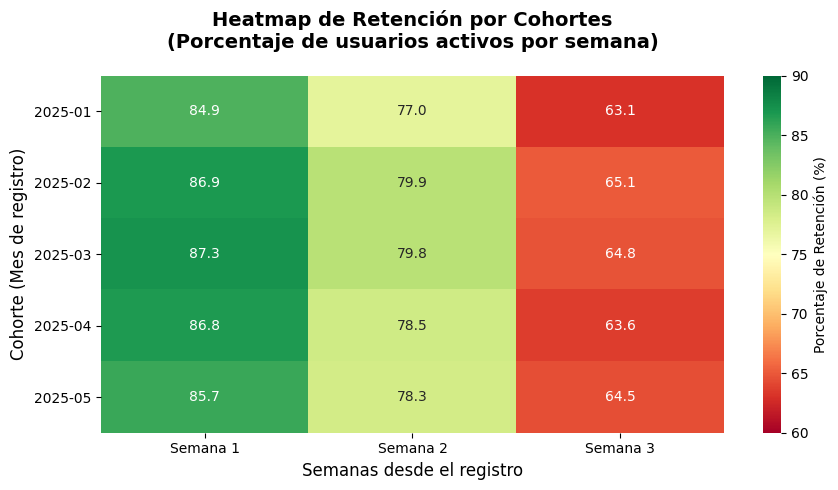

In [ ]:
# Crear el heatmap de retención
def crear_heatmap_retencion(df_retencion):
    # Preparar los datos para el heatmap
    # Seleccionar solo las columnas de porcentajes de retención
    datos_heatmap = df_retencion.set_index('cohorte')[['retencion_w1_pct', 'retencion_w2_pct', 'retencion_w3_pct']]

    # Renombrar columnas para mejor visualización
    datos_heatmap.columns = ['Semana 1', 'Semana 2', 'Semana 3']

    # Crear la figura
    plt.figure(figsize=(9, 5))

    # Crear el heatmap
    sns.heatmap(datos_heatmap,
                annot=True,           # Mostrar valores en cada celda
                fmt='.1f',            # Formato de números (1 decimal)
                cmap='RdYlGn',        # Paleta de colores (rojo-amarillo-verde)
                center=75,            # Centrar la escala de colores en 75%
                vmin=60,              # Valor mínimo para la escala
                vmax=90,              # Valor máximo para la escala
                cbar_kws={'label': 'Porcentaje de Retención (%)'})

    # Personalizar el gráfico
    plt.title('Heatmap de Retención por Cohortes\n(Porcentaje de usuarios activos por semana)',
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Semanas desde el registro', fontsize=12)
    plt.ylabel('Cohorte (Mes de registro)', fontsize=12)

    # Rotar etiquetas del eje x para mejor legibilidad
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Ajustar el layout
    plt.tight_layout()

    return plt

# Usar tu DataFrame de retención
heatmap = crear_heatmap_retencion(cohorte_final)
plt.show()

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** La tasa de conversión es igual en ambas páginas.
   - **H₁ (Hipótesis alternativa):** La tasa de conversión es diferente entre ambas páginas.

In [ ]:
# Cargar el dataset del experimento A/B
experiment_data = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

In [ ]:
# Explorar el dataset
print("Información del dataset:")
experiment_data.info()
print("\nPrimeras filas:")
experiment_data.head()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB

Primeras filas:


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


**Hallazgos**
- El dataset no tiene valores nulos.
- La columna `timestamp` tiene tipo de dato object, en caso de ser necesario para el análisis, se debe cambiar a tipo de dato datetime con pd.to_datetime
- Todas las columnas tienen 10.000 registros no nulos.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `id_usuario` - Identificador único del usuario en el experimento.
- `variante` - Variante del experimento asignada al usuario (control o tratamiento).
- `convirtio` - Indicador de conversión (1 = convirtió, 0 = no convirtió).
- `dispsitivo`- Dispositivo utilizado por el usuario.
- `pais` - País del usuario.
- `duracion_sesion` - Duración de la sesión del usuario en segundos.
- `timestamp` - Fecha en la que ocurrió la interacción.

**Análisis exploratorio y revisión de calidad de datos**
- Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.

In [ ]:
# Verificar usuarios úmicos
print(f"Usuarios únicos: {experiment_data['id_usuario'].nunique()}")

Usuarios únicos: 10000


In [ ]:
# Variable timestamp
# Explorar rango de fechas
# Resumen estadístico
experiment_data['timestamp'].describe()

count          10000
unique           181
top       2025-06-06
freq              75
Name: timestamp, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", experiment_data['timestamp'].min())
print("Fecha máxima:", experiment_data['timestamp'].max())

Fecha mínima: 2025-01-01
Fecha máxima: 2025-06-30


**Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("Conteo de categorías:\n")
print(f"Conteo de variante: \n{experiment_data['variante'].value_counts()}\n")
print(f"Conteo de conversión: \n{experiment_data['convirtio'].value_counts()}\n")
print(f"Conteo de dispositivo: \n{experiment_data['dispositivo'].value_counts()}\n")
print(f"Conteo de país: \n{experiment_data['pais'].value_counts()}")

Conteo de categorías:

Conteo de variante: 
tratamiento    5035
control        4965
Name: variante, dtype: int64

Conteo de conversión: 
0    8401
1    1599
Name: convirtio, dtype: int64

Conteo de dispositivo: 
desktop    5042
mobile     4958
Name: dispositivo, dtype: int64

Conteo de país: 
Mexico       3405
Argentina    3317
Colombia     3278
Name: pais, dtype: int64


In [ ]:
# Categorías por proporción
print("Proporción por categorías:\n")
print(f"Proporción de variante: \n{experiment_data['variante'].value_counts(normalize=True)*100}\n")
print(f"Proporción de conversión: \n{experiment_data['convirtio'].value_counts(normalize=True)*100}\n")
print(f"Proporción de dispositivo: \n{experiment_data['dispositivo'].value_counts(normalize=True)*100}\n")
print(f"Proporción de país: \n{experiment_data['pais'].value_counts(normalize=True)*100}")

Proporción por categorías:

Proporción de variante: 
tratamiento    50.35
control        49.65
Name: variante, dtype: float64

Proporción de conversión: 
0    84.01
1    15.99
Name: convirtio, dtype: float64

Proporción de dispositivo: 
desktop    50.42
mobile     49.58
Name: dispositivo, dtype: float64

Proporción de país: 
Mexico       34.05
Argentina    33.17
Colombia     32.78
Name: pais, dtype: float64


✍️ **Hallazgos**
- No se observan categorías con nombres incorrectos, ni valores nulos.
- Los valores de la variante del experimento están balanceados, esto evita sesgos en el análisis.
- Solo convirtieron 1.599 de 10.000 usuarios, con un porcentaje del 15.99%
- Las proporciones de los tipos de dispositivos son muy similares.
- Las proporciones por países también son muy similares entre sí.

**Las categorías dominantes son:**
- Tratamiento con 50.35%
- Desktop con 50.42%
- México con 34.05%

In [ ]:
# Calcular cuantos usuarios se convirtieron en clientes
conversiones= experiment_data.groupby('variante')['convirtio'].sum()
print(f"Cantidad de usuarios que convirtieron:\n{conversiones}")

Cantidad de usuarios que convirtieron:
variante
control        779
tratamiento    820
Name: convirtio, dtype: int64


In [ ]:
# Calcular total de usuarios de cada página
totales= experiment_data.groupby('variante')['convirtio'].count()
print(f"Cantidad de usuarios por página: \n{totales}")

Cantidad de usuarios por página: 
variante
control        4965
tratamiento    5035
Name: convirtio, dtype: int64


In [ ]:
# Organizar los datos en listas
# Total de éxitos por grupo
exitos= [conversiones['control'], conversiones['tratamiento']]
exitos

[779, 820]

In [ ]:
# Total de observaciones por grupo
observaciones= [totales['control'], totales['tratamiento']]
observaciones

[4965, 5035]

**Test estadístico:**

In [ ]:
# Aplicar prueba y visualizar resultados
z_stat, p_value= proportions_ztest(exitos, observaciones)
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -0.8132782986429474
Valor p: 0.41605851639119995


**Nivel de significancia alpha:**

In [ ]:
# Obtener la interpretación
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.


- En este caso, el valor p es alto y es mayor al umbral, entonces tenemos evidencia suficiente para rechazar la hipótesis alternativa.
- No hay una diferencia significativa entre ambas páginas.

In [ ]:
# Calcular tasas de conversión
# Obtener tasa o porcentaje de éxito
tasa_control = exitos[0] / observaciones[0]
tasa_tratamiento = exitos[1] / observaciones[1]

print(f"Tasa de conversión página control: {tasa_control:.2%}")
print(f"Tasa de conversión página tratamiento: {tasa_tratamiento:.2%}")

# Interpretar dirección de resultados
if tasa_control > tasa_tratamiento:
    print(f"\nLa página control tiene una mayor tasa de conversión ({tasa_control - tasa_tratamiento:.2%}).")
elif tasa_tratamiento > tasa_control:
    print(f"\nLa página tratamiento tiene una mayor tasa de conversión ({tasa_tratamiento - tasa_control:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")

Tasa de conversión página control: 15.69%
Tasa de conversión página tratamiento: 16.29%

La página tratamiento tiene una mayor tasa de conversión (0.60%)


- Las tasas de conversión son similares.

### Conclusión e interpretación

**Decisión:**  
- No se rechaza la hipótesis nula, no hay evidencia de una diferencia significativa entre las tasas de conversión de la variante control y tratamiento.

**Interpretación de negocio:**
- Con base en un z-test para proporciones, se encontró evidencia estadística de que la tasa de conversión no difiere significativamente entre la página A y la página B.
- La tasa de conversión de la UI control es 15.69%
- La tasa de conversión de la UI tratamiento es 16.29%
- La tasa de conversión de la UI tratamiento es mayor 0.60% que la UI control.
- Este resultado sugiere que la conversión de la UI tratamiento es levemente mayor que la UI control.
- Conclusión: No hay evidencia de una diferencia estadísticamente significativa.

**Limitaciones:**
- La conversión se mide como evento binario (sí / no).
- El análisis asume observaciones independientes.
- El test actual no justifica los recursos de implementación.
- Se necesita mayor evidencia antes de hacer cambios.

**Recomendaciones:**
- Valor p: 0.4160: Aún no se recomienda un cambio general de la UI del checkout, ya que no se encontró evidencia estadísticamente significativa de mejora en la conversión.
- Continuar con la interfaz de checkout actual (control).
- No hay justificación estadística para el cambio.
- El resultado del z-test sugiere que se deben evitar costos innecesarios de implementación.
- Aumentar el tamaño de muestra para detectar diferencias menores.
- Diseñar un nuevo test con cambios más sustanciales.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.



## Narrativa del Dashboard (Modelo SCQA)

**Vista General (Overview)**

🎯 SITUACIÓN (Situation)
- RappiPlus busca aumentar la frecuencia de compra y el valor por usuario a través de su servicio de suscripción.

Contexto adicional:
- Servicio activo en múltiples países (Argentina, México, Colombia)
- Diverso portafolio de productos (Laptop Gaming, Blender, etc.)
- Inversión significativa en marketing (2.87M en 2025)

⚠️ COMPLICACIÓN (Complication)
- "Existen dudas críticas sobre la rentabilidad y efectividad del modelo de negocio."

Puntos específicos del análisis:
- Revenue total: 51.9M vs Costos: 43.1M
- Ganancia bruta total: 8.85M
- Junio mostró el peor desempeño en ganancia bruta (399 mil).
- Abril mostró el peor desempeño en ventas totales (1.6M).
- Algunos países/productos pueden estar generando pérdidas.

❓ PREGUNTA (Question)
- ¿Está RappiPlus cumpliendo realmente sus objetivos de rentabilidad y crecimiento?

Preguntas específicas:
- ¿Los usuarios realmente compran más?
- ¿El modelo está generando ganancias?
- ¿Se están perdiendo oportunidades en el proceso de compra?

💡 RESPUESTA (Answer)
- Basado en el análisis de datos del primer semestre del 2025, RappiPlus muestra signos positivos pero con oportunidades de optimización.

Hallazgos clave:

✅ Fortalezas:
- Profit positivo: Ganancia bruta de 8.85M (17% de margen).
- Ganancia neta, después de gastos de marketing: 5.9M (11.5% de margen). El modelo está generando ganancias.
- Crecimiento acumulado: Tendencia ascendente hasta junio. Esto sugiere que los usuarios compran más.
- Liderazgo geográfico: Argentina lidera con 21M en ingresos.
- Producto estrella: Laptop Gaming 16GB genera 43M en el semestre.

⚠️ Áreas de mejora:
- Estacionalidad crítica: Abril requiere estrategia específica.
- Diversificación: Dependencia alta en pocos productos.
- Eficiencia de marketing: ROI del gasto de $2.87M debería evaluarse al detalle.
- La mayor pérdida de usuarios ocurre entre begin_checkout y add_payment_info, 958 usuarios abandonan en esta etapa, en la cual se debe enfocar la optimización.

## Resumen ejecutivo

**Hallazgos clave**

**Dataset orders**
- Se encontraron 4 registros con ingresos negativos, decidí eliminar los 4 registros, ya que no es posible que haya ventas negativas. Los registros eliminados no son representativos, equivalían al 0.016% de los datos.

- Se encontraron celdas con datos vacíos, los cuales se reemplazaron con los textos 'Pais_sin_especificar', 'Dispositivo_desconocido', 'Canal_desconocido', 'Producto_no_especificado', 'Categoria_no_especificada'.

- Se encontraron 100 filas exactas duplicadas, posteriormente se eliminaron.
- Se estandarizaron los nombres de todas las variables.
- Luego de la limpieza el dataset quedó con 24.996 registros no nulos.

**Dataset marketing**
- Se encontraron 101 datos faltantes en la columna `canal`. Los datos se extrajeron la columna `id_campaña` del mismo dataset.
- Se estandarizaron los nombres de todas las variables.

**Dataset catalog**
- Se creó el producto_no_especificado con el costo promedio de todos los productos del dataset.
- Se estandarizaron los nombres de todas las variables.
  

**Métricas principales**
- Revenue total: 51.988.610
- Costo total de productos: 43.136.745
- Gasto total en marketing: 2.871.844
- Costo total (Costo total productos + Gasto total Marketing): 46.008.588
- Profit(Ganancia bruta): 8.851.865
- Ganancia neta: 5.980.021
- Margen de profit: 17%
- Margen de ganancia neta: 11.5%
- Ticket promedio total: 2079.88
- Cantidad promedio de productos por orden: 7

  
**Insights accionables**
- El negocio es rentable, genera una utilidad neta de 5.980.021 con un margen de utilidad del 11.50%
- El producto más vendido es el Laptop-Gaming-16GB con 144.206 unidades.
- La mayor pérdida de usuarios ocurre entre begin_checkout y add_payment_info
- 958 usuarios abandonan en esta etapa, en la cual se debe enfocar la optimización.
- La tasa de conversión final es 80.04%
- De 7796 usuarios, 6240 finalizaron la compra exitosamente.
- La retención de usuarios va disminuyendo gradualmente semana tras semana.
- La semana tres es la más crítica, presenta el menor porcentaje de retención de usuarios.
- El promedio de retención de la semana tres es 64.22
- Experimento Checkout UI: El resultado de la modificación en la UI del checkout, sugiere que no impacta la tasa de conversión de compra.
- Con base en un z-test para proporciones, se encontró evidencia estadística de que la tasa de conversión no difiere significativamente entre la página A y la página B.
- Se obtuvo un valor p (0.41): En este caso, el valor p es alto y es mayor al umbral, entonces tenemos evidencia suficiente para rechazar la hipótesis alternativa. No hay evidencia de una diferencia estadísticamente significativa entre ambas páginas.
- Tasa de conversión página control: 15.69%
- Tasa de conversión página tratamiento: 16.29%
- La página tratamiento tiene una mayor tasa de conversión (0.60%). Las tasas de conversión son similares.

  
**Recomendaciones estratégicas**

1. Rentabilidad (Margen neto 11.50%):
- Establecer meta de margen del 15% para 2026.
- Estrategia: Revisar estructura de costos de productos menos rentables.
- Revisar estructura de costos de productos con Profit negativo, no se debe vender productos por debajo del valor de adquisición.
- Establecer un precio mínimo de venta, por ejemplo: Costo producto +5%
- Monitoreo: Dashboard mensual de margen por producto/país.

2. Producto estrella: Laptop Gaming (144,206 unidades)
- Aprovechar el éxito, hacer énfasis en campañas de marketing.
- Expansión: Lanzar variantes (32GB, diferentes marcas).
- Cross-selling: Vender con accesorios gaming complementarios (mouse, teclados).
- Marketing: Campañas específicas para gamers en todos los países.
  
3. Optimización del checkout:
- Análisis UX: Revisar flujo de checkout paso a paso.
- A/B Testing: Probar checkout simplificado (menos pasos).
- Opciones de pago: Agregar más métodos de pago locales, pagos con llaves en Bre-b.
- Indicadores de confianza: Sellos de seguridad, testimonios.
- Implementar estrategias de recuperación de usuarios con mensajes, pequeños incentivos.

4. Abandono en add_payment_info (958 usuarios)
- Optimización de pagos.
- Autocompletado: Guardar métodos de pago frecuentes.
- Pago express: Integrar Apple Pay, Google Pay.
- Transparencia: Mostrar costos totales antes del pago.
- Soporte: Chat en vivo durante el proceso de pago.
  
5. Conversión final 80.04%
  Mejorar los últimos pasos:
- Confirmación clara: Página de confirmación más atractiva.
- Urgencia: "Solo quedan X unidades" en productos populares.
- Incentivos: Descuento por completar compra en X minutos.
  
6. Retención decreciente (semana 3 crítica)
 Estrategia de retención:
- Email de bienvenida con tips de uso.
- Descuento en segunda compra (5% al 10%)
- Campaña de reactivación: "Te extrañamos" con oferta especial.
- Contenido de valor: Guías de productos, reviews.
- Notificaciones push: Productos recomendados personalizados
- Programa de lealtad: Puntos por compras.
- Navegación: Menú más intuitivo y búsqueda mejorada.

7. Recomendaciones sobre experimento Checkout UI
- Valor p: 0.4160: Aún no se recomienda un cambio general de la UI del checkout, ya que no se encontró evidencia estadísticamente significativa de mejora en la conversión.
- Continuar con la interfaz de checkout actual (control).
- No hay justificación estadística para el cambio.
- El resultado del z-test sugiere que se deben evitar costos innecesarios de implementación.
- Aumentar el tamaño de muestra para detectar diferencias menores.
- Diseñar un nuevo test con cambios más sustanciales.


---